# Fastest-Growing Regions for Counter-Strike

**Purpose:** generalizes `research/esports_lifecycle_and_maturity/notebooks/china_cs_scene.ipynb`'s single-country
approach across every country with usable data. China motivated this
notebook (its grassroots tournament *count* looked like a growth story at
first), but the honest answer turns out to be more specific than "China is
growing fastest" -- see §7.

**Restructured 2026-09-11** to lead with real year-by-year trajectories,
not just a two-window before/after ratio. The first version of this
notebook used an EARLY (2016-18) vs RECENT (2023-25) comparison to screen
for interesting countries, deliberately skipping 2019-2022's COVID
whipsaw -- a reasonable way to avoid *that* distortion, but it introduced
a different one: a country that spiked mid-window and has since declined
looks identical, by that ratio, to one still climbing. Checked directly
and found real cases of exactly that (§2 below) -- the two-window ratio
is kept only as an initial screen; every country it flags is now shown as
a full year-by-year series before any growth claim is made about it.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

from etl.db import get_connection

conn = get_connection()
plt.rcParams["figure.dpi"] = 110

EARLY = ("2016", "2019")
RECENT = ("2023", "2026")

## 1. Country mapping and helpers

Reuses `title_geography_maps.ipynb`'s `COUNTRY_TO_ISO3`/`EXCLUDED_COUNTRY`
mapping, with `grassroots_scene_comparison.ipynb`'s extensions.

In [2]:
# ISO-3 mapping, keyed on the lowercased raw string. Covers every genuine
# country/alias/2-letter-code actually observed in tournaments.country --
# built and tested against the real distinct-value distribution, not
# guessed at scale (tested: 8,429 of 16,300 tier-1/2 rows with a country
# value map cleanly, 7,870 are real continents/regions/placeholders
# (EXCLUDED_COUNTRY, below), and exactly 1 row -- "bs", genuinely
# ambiguous between Bahamas and Bosnia -- falls through unmapped).
COUNTRY_TO_ISO3 = {
    "united states": "USA", "usa": "USA", "us": "USA", "united states of america": "USA",
    "china": "CHN", "cn": "CHN",
    "south korea": "KOR", "korea": "KOR", "kr": "KOR",
    "brazil": "BRA", "brasil": "BRA", "br": "BRA",
    "japan": "JPN", "jp": "JPN",
    "germany": "DEU", "de": "DEU",
    "france": "FRA", "fr": "FRA",
    "taiwan": "TWN", "tw": "TWN",
    "sweden": "SWE", "se": "SWE",
    "australia": "AUS",
    "vietnam": "VNM", "vn": "VNM",
    "united kingdom": "GBR", "uk": "GBR", "england": "GBR", "scotland": "GBR",
    "thailand": "THA", "th": "THA",
    "malaysia": "MYS", "my": "MYS",
    "saudi arabia": "SAU", "sa": "SAU",
    "indonesia": "IDN",
    "canada": "CAN", "ca": "CAN",
    "india": "IND",
    "russia": "RUS", "ru": "RUS",
    "mexico": "MEX", "méxico": "MEX", "mx": "MEX",
    "philippines": "PHL",
    "poland": "POL", "pl": "POL",
    "ukraine": "UKR", "ua": "UKR",
    "turkey": "TUR", "turkiye": "TUR", "türkiye": "TUR", "tr": "TUR",
    "spain": "ESP", "es": "ESP",
    "finland": "FIN",
    "romania": "ROU", "ro": "ROU",
    "chile": "CHL",
    "italy": "ITA",
    "pakistan": "PAK",
    "netherlands": "NLD", "nl": "NLD",
    "united arab emirates": "ARE", "ae": "ARE",
    "south africa": "ZAF",
    "hong kong": "HKG",
    "peru": "PER",
    "belgium": "BEL",
    "denmark": "DNK", "dk": "DNK",
    "cambodia": "KHM",
    "norway": "NOR", "no": "NOR",
    "dominican republic": "DOM",
    "argentina": "ARG",
    "puerto rico": "PRI",
    "myanmar": "MMR",
    "ireland": "IRL", "ie": "IRL",
    "macau": "MAC",
    "kazakhstan": "KAZ",
    "greece": "GRC",
    "bulgaria": "BGR",
    "austria": "AUT", "at": "AUT",
    "bangladesh": "BGD",
    "costa rica": "CRI",
    "colombia": "COL",
    "portugal": "PRT",
    "belarus": "BLR", "by": "BLR",
    "azerbaijan": "AZE",
    "uzbekistan": "UZB",
    "serbia": "SRB",
    "new zealand": "NZL",
    "croatia": "HRV",
    "armenia": "ARM",
    "switzerland": "CHE", "ch": "CHE",
    "nepal": "NPL",
    "malta": "MLT",
    "madagascar": "MDG",
    "ivory coast": "CIV",
    "bolivia": "BOL",
    "qatar": "QAT",
    "mongolia": "MNG", "mn": "MNG",
    "laos": "LAO",
    "hungary": "HUN",
    "georgia": "GEO",
    "czech republic": "CZE", "czechia": "CZE", "cz": "CZE",
    "sint maarten": "SXM",
    "maldives": "MDV",
    "kuwait": "KWT",
    "israel": "ISR",
    "iran": "IRN",
    "iceland": "ISL",
    "brunei": "BRN",
    "venezuela": "VEN",
    "turkmenistan": "TKM",
    "tajikistan": "TJK",
    "slovenia": "SVN",
    "slovakia": "SVK", "sk": "SVK",
    "panama": "PAN",
    "morocco": "MAR",
    "lithuania": "LTU",
    "kyrgyzstan": "KGZ",
    "jordan": "JOR",
    "egypt": "EGY",
    "cyprus": "CYP",
    "andorra": "AND",
    "singapore": "SGP", "sg": "SGP",
}

# Continents, macro-regions, and placeholders -- real values, but not a
# single country, so excluded rather than force-mapped to one arbitrary
# member. "kosovo" included here too: a real place, but no standard ISO-3
# code in plotly's built-in reference.
EXCLUDED_COUNTRY = {
    "north america", "europe", "world", "south america", "asia", "oceania",
    "southeast asia", "middle east", "cis", "americas", "africa", "mena",
    "asia-pacific", "south asia", "latin america", "apac", "east asia",
    "sea", "latin america north", "emea", "central america", "latam",
    "global", "northeast asia", "asia pacific", "sub-saharan africa",
    "middle east and north africa", "oce", "eu", "benelux", "nordic",
    "nordics", "western europe", "eastern europe", "latin america south",
    "las", "lan", "tbd", "north americas", "kosovo",
}

EXTRA_COUNTRY_TO_ISO3 = {
    "latvia": "LVA", "estonia": "EST", "bosnia and herzegovina": "BIH",
    "lebanon": "LBN", "albania": "ALB", "north macedonia": "MKD",
    "macedonia": "MKD", "czech": "CZE", "sri lanka": "LKA", "ecuador": "ECU",
    "algeria": "DZA", "tunisia": "TUN", "montenegro": "MNE", "moldova": "MDA",
    "paraguay": "PRY", "mauritius": "MUS", "uruguay": "URY", "cuba": "CUB",
    "wales": "GBR", "perú": "PER", "au": "AUS",
    "guatemala": "GTM", "syria": "SYR", "uae": "ARE", "nigeria": "NGA",
    "senegal": "SEN", "faroe islands": "FRO", "bahrain": "BHR", "iraq": "IRQ",
    "palestine": "PSE", "bg": "BGR", "ph": "PHL", "martinique": "MTQ",
    "kazakhstan": "KAZ", "uzbekistan": "UZB",
}
COUNTRY_TO_ISO3.update(EXTRA_COUNTRY_TO_ISO3)

GRASSROOTS = "tier NOT IN ('S-Tier','A-Tier')"
TIER12 = "tier IN ('S-Tier','A-Tier')"

def by_country(tier_filter, lo, hi, extra_cols=""):
    rows = conn.execute(
        f"SELECT country{extra_cols} FROM tournaments WHERE title_id='counter_strike' "
        f"AND {tier_filter} AND country IS NOT NULL AND start_date >= ? AND start_date < ?",
        (lo, hi),
    ).fetchall()
    cols = ["country_raw"] + [c.strip() for c in extra_cols.split(",") if c.strip()]
    df = pd.DataFrame(rows, columns=cols)
    df["key"] = df["country_raw"].str.strip().str.lower()
    df["iso3"] = df["key"].map(COUNTRY_TO_ISO3)
    return df[df["iso3"].notna()]

def yearly_by_country(tier_filter, iso3_list, lo=2016, hi=2027, extra_cols="", value_col=None):
    """Full year-by-year series for a specific set of countries -- the
    main tool this notebook now leans on, not the two-window ratio."""
    rows = conn.execute(
        f"SELECT country, substr(start_date,1,4) AS yr{extra_cols} FROM tournaments "
        f"WHERE title_id='counter_strike' AND {tier_filter} AND country IS NOT NULL "
        f"AND start_date GLOB '[0-9][0-9][0-9][0-9]-*'",
    ).fetchall()
    cols = ["country_raw", "yr"] + [c.strip() for c in extra_cols.split(",") if c.strip()]
    df = pd.DataFrame(rows, columns=cols)
    df["key"] = df["country_raw"].str.strip().str.lower()
    df["iso3"] = df["key"].map(COUNTRY_TO_ISO3)
    df["yr"] = df["yr"].astype(int)
    df = df[(df["iso3"].isin(iso3_list)) & (df["yr"] >= lo) & (df["yr"] < hi)]
    if value_col:
        df = df[df[value_col].notna()]
        return df.groupby(["iso3", "yr"])[value_col].sum().unstack(fill_value=0)
    return df.groupby(["iso3", "yr"]).size().unstack(fill_value=0)

print("Setup complete.")

Setup complete.


## 2. Grassroots tournament count — screen, then trajectory

First, the same two-window screen as before, to shortlist candidates.

In [3]:
def grassroots_counts(lo, hi):
    df = by_country(GRASSROOTS, lo, hi)
    return df["iso3"].value_counts()

g_early = grassroots_counts(*EARLY)
g_recent = grassroots_counts(*RECENT)
g_growth = pd.DataFrame({"early": g_early, "recent": g_recent}).fillna(0)
g_growth["ratio"] = g_growth["recent"] / g_growth["early"].replace(0, pd.NA)

established = g_growth[g_growth["early"] >= 15].sort_values("ratio", ascending=False)
print("Established scenes (>=15 events in 2016-18), ranked by growth ratio:")
print(established.head(8).to_string())

new_entrants = g_growth[(g_growth["early"] < 5) & (g_growth["recent"] >= 15)].sort_values("recent", ascending=False)
print("\nNew entrants (near-zero in 2016-18, >=15 events by 2023-25):")
print(new_entrants.to_string())

Established scenes (>=15 events in 2016-18), ranked by growth ratio:
      early  recent     ratio
iso3                         
RUS    41.0    75.0  1.829268
CZE    22.0    37.0  1.681818
ARG    19.0    30.0  1.578947
ZAF    37.0    46.0  1.243243
CHN   170.0   185.0  1.088235
PRT    34.0    37.0  1.088235
GBR    50.0    50.0       1.0
NOR    22.0    20.0  0.909091

New entrants (near-zero in 2016-18, >=15 events by 2023-25):
      early  recent ratio
iso3                     
KAZ     1.0    37.0  37.0
UZB     0.0    25.0  <NA>


Now the actual year-by-year shape for everyone this screen flagged,
plus China for context (the country that started the question).

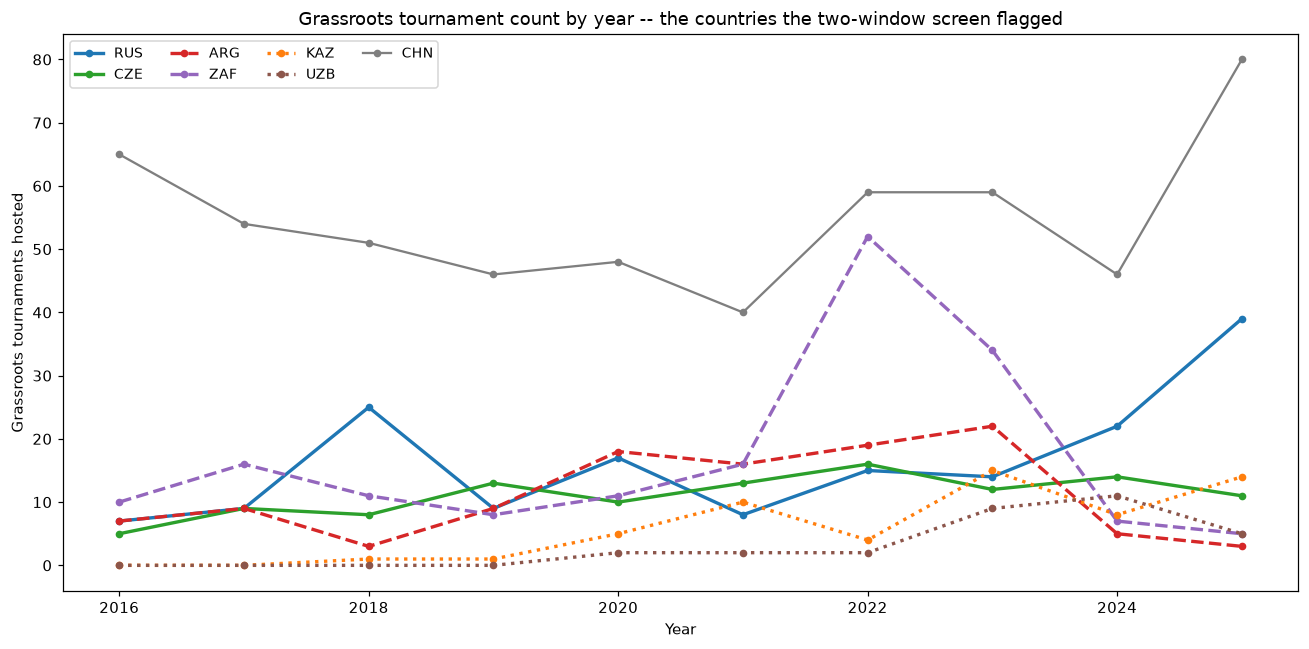

yr    2016  2017  2018  2019  2020  2021  2022  2023  2024  2025
iso3                                                            
ARG      7     9     3     9    18    16    19    22     5     3
CHN     65    54    51    46    48    40    59    59    46    80
CZE      5     9     8    13    10    13    16    12    14    11
KAZ      0     0     1     1     5    10     4    15     8    14
RUS      7     9    25     9    17     8    15    14    22    39
UZB      0     0     0     0     2     2     2     9    11     5
ZAF     10    16    11     8    11    16    52    34     7     5


In [4]:
focus = ["RUS", "CZE", "ARG", "ZAF", "KAZ", "UZB", "CHN"]
yearly_g = yearly_by_country(GRASSROOTS, focus, lo=2016, hi=2026)
yearly_g = yearly_g.reindex(columns=range(2016, 2026), fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
colors = {"RUS": "#1f77b4", "CZE": "#2ca02c", "ARG": "#d62728", "ZAF": "#9467bd",
          "KAZ": "#ff7f0e", "UZB": "#8c564b", "CHN": "#7f7f7f"}
for iso3 in focus:
    style = "-" if iso3 in ("RUS", "CZE") else ("--" if iso3 in ("ARG", "ZAF") else (":" if iso3 in ("KAZ", "UZB") else "-"))
    lw = 1.5 if iso3 == "CHN" else 2.2
    ax.plot(yearly_g.columns, yearly_g.loc[iso3], style, color=colors[iso3], linewidth=lw, marker="o", markersize=4, label=iso3)
ax.set_xlabel("Year")
ax.set_ylabel("Grassroots tournaments hosted")
ax.set_title("Grassroots tournament count by year -- the countries the two-window screen flagged")
ax.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.savefig(Path.cwd() / "_regions_fig_grassroots_yearly.png", dpi=110)
plt.show()

print(yearly_g.to_string())

**The two-window screen was wrong about two of its four "established
growers" — not noisy, wrong.** Argentina and South Africa didn't grow
steadily into 2023-25; both **spiked mid-window and have since
collapsed**: Argentina peaked at 22 events in 2023 then fell to 5 (2024)
and 3 (2025) — a 2025 total *below* 2016's starting point (7). South
Africa spiked hard in 2022 (52 events, from single digits before) then
fell to 34 (2023), 7 (2024), 5 (2025) — also now below where it started.
The EARLY/RECENT ratio happened to land its RECENT window (2023-2025)
right on top of each spike's tail, which is exactly the failure mode this
restructuring was meant to catch. **Confirmed not a late-2025-crawl
artifact**: both countries' 2025 events are spread across the full
calendar year (Jan-Oct), not missing from an incomplete recent window.

**Russia and Czech Republic hold up as genuine growers**, and look
different from each other in shape: Czech Republic's growth is gradual
and steady (5→9→8→13→10→13→16→12→14→11 -- noisy but with no real
collapse), while Russia's is volatile with a clear recent acceleration
(14→22→39 in 2023-2025 specifically, its three best years in the whole
window). **Kazakhstan and Uzbekistan's emergence is real but genuinely
bumpy, not a smooth ramp** -- Kazakhstan peaks at 15 (2023), dips to 8
(2024), recovers to 14 (2025); Uzbekistan peaks at 11 (2024) then falls
to 5 (2025). Real new scenes, not yet a settled trajectory.

**China is closer to flat-with-a-recent-jump than either "modest growth"
or "not growing"** -- oscillating in the 40s-60s most years, then a clear
jump to 80 in 2025, its highest year in the window. The 3-year RECENT
average (2023-25: 59, 46, 80) smoothed over that 2025 jump being
genuinely new, not a continuation of a trend already visible earlier.

## 3. Tier-1/2 tournament count — prestige hosting, year by year

Much sparser (single-digit events/country/year), so a small-multiples grid
of the actual yearly bars is more honest here than any single ratio or
overlaid line chart would be.

In [5]:
def tier12_counts(lo, hi):
    df = by_country(TIER12, lo, hi)
    return df["iso3"].value_counts()

t_early = tier12_counts(*EARLY)
t_recent = tier12_counts(*RECENT)
t_growth = pd.DataFrame({"early": t_early, "recent": t_recent}).fillna(0)
t_growth["ratio"] = t_growth["recent"] / t_growth["early"].replace(0, pd.NA)

print("Established tier-1/2 hosts (>=3 events in 2016-18):")
print(t_growth[t_growth["early"] >= 3].sort_values("ratio", ascending=False).to_string())
new_entrants = t_growth[(t_growth["early"] < 2) & (t_growth["recent"] >= 3)].sort_values("recent", ascending=False)
print("\nNew tier-1/2 entrants:")
print(new_entrants.to_string())

Established tier-1/2 hosts (>=3 events in 2016-18):
      early  recent     ratio
iso3                         
DNK     6.0    13.0  2.166667
AUS     3.0     4.0  1.333333
POL     7.0     6.0  0.857143
ROU     9.0     6.0  0.666667
CHN    15.0     9.0       0.6
DEU     7.0     4.0  0.571429
SWE    11.0     6.0  0.545455
USA    38.0    10.0  0.263158
ESP     4.0     1.0      0.25
FRA     5.0     1.0       0.2
GBR    13.0     2.0  0.153846
CAN     5.0     0.0       0.0
MYS     3.0     0.0       0.0
RUS     7.0     0.0       0.0
UKR     8.0     0.0       0.0

New tier-1/2 entrants:
      early  recent ratio
iso3                     
MLT     1.0     7.0   7.0
SRB     1.0     6.0   6.0
IND     0.0     5.0  <NA>
ARE     1.0     4.0   4.0
MNG     0.0     3.0  <NA>
SAU     0.0     3.0  <NA>


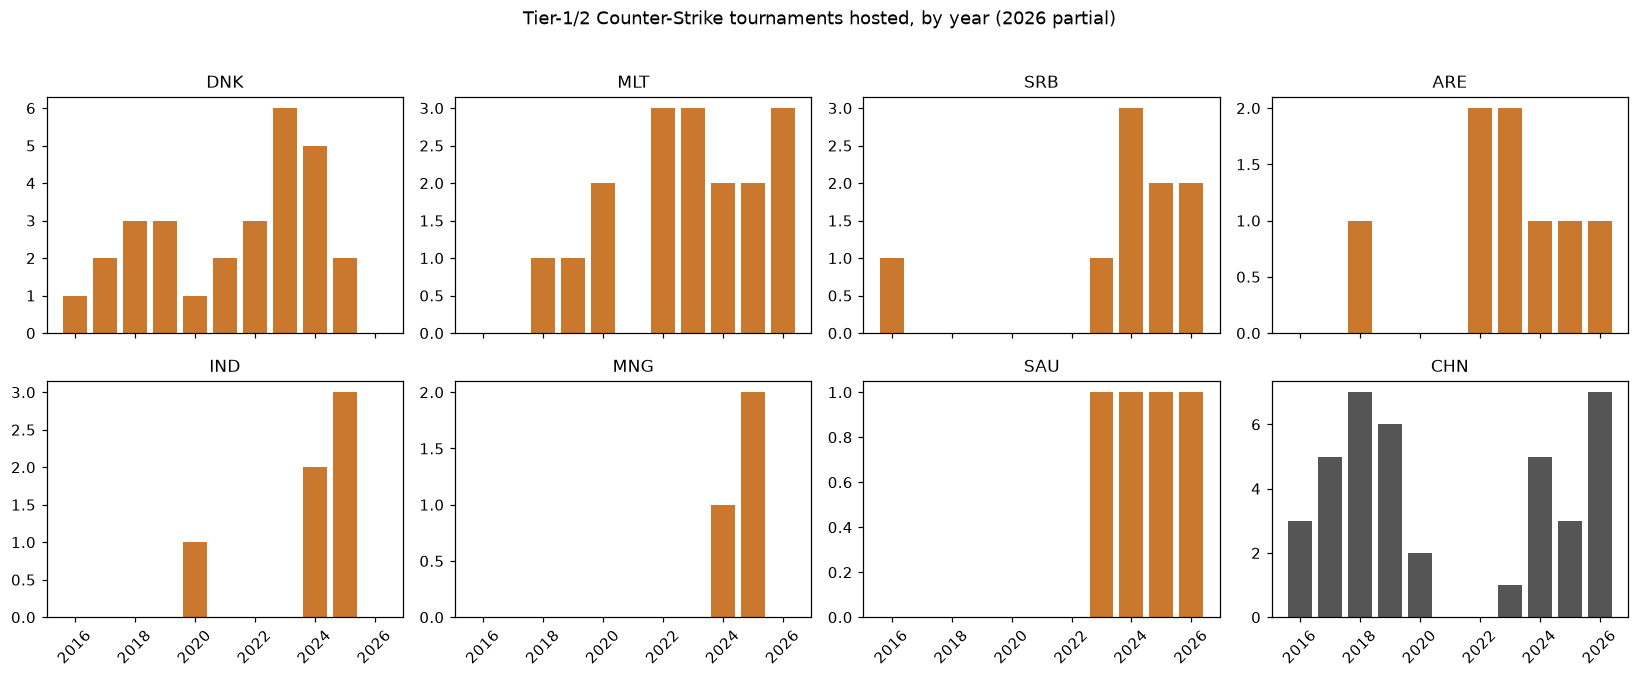

yr    2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
iso3                                                                  
ARE      0     0     1     0     0     0     2     2     1     1     1
CHN      3     5     7     6     2     0     0     1     5     3     7
DNK      1     2     3     3     1     2     3     6     5     2     0
IND      0     0     0     0     1     0     0     0     2     3     0
MLT      0     0     1     1     2     0     3     3     2     2     3
MNG      0     0     0     0     0     0     0     0     1     2     0
SAU      0     0     0     0     0     0     0     1     1     1     1
SRB      1     0     0     0     0     0     0     1     3     2     2


In [6]:
focus_t = ["DNK", "MLT", "SRB", "ARE", "IND", "MNG", "SAU", "CHN"]
yearly_t = yearly_by_country(TIER12, focus_t, lo=2016, hi=2027)
yearly_t = yearly_t.reindex(columns=range(2016, 2027), fill_value=0)

fig, axes = plt.subplots(2, 4, figsize=(15, 6), sharex=True, sharey=False)
for ax, iso3 in zip(axes.flat, focus_t):
    ax.bar(yearly_t.columns, yearly_t.loc[iso3], color="#c9782e" if iso3 != "CHN" else "#555555")
    ax.set_title(iso3, fontsize=11)
    ax.set_ylim(bottom=0)
    ax.tick_params(axis="x", rotation=45)
plt.suptitle("Tier-1/2 Counter-Strike tournaments hosted, by year (2026 partial)", y=1.02)
plt.tight_layout()
plt.savefig(Path.cwd() / "_regions_fig_tier12_yearly.png", dpi=110)
plt.show()

print(yearly_t.to_string())

**Denmark's growth is real but volatile, not a clean climb**:
1→2→3→3→1→2→3→**6**→5→2→0 (2026 still has months to go). Its 2023 peak
(6) is real, but 2024-25 already pulled back toward its historical range
before 2026 even started -- worth watching, not yet a settled "Denmark is
growing" story.

**China's tier-1/2 panel makes §18's two-collapse pattern (`china_cs_scene.
ipynb`) visible again here, exactly as that notebook found independently**
-- 3→5→7→6→2→**0→0**→1→5→3→7, the two real zero-years standing out clearly
against every other country in this set, none of which ever hit zero.

**The new entrants are all genuinely small and recent, not yet
trajectories in their own right** -- Saudi Arabia (1 event/year since
2023), Mongolia (1-2/year since 2024), India (1-3/year since 2020, still
irregular), Serbia and Malta (2-3/year, bumpy). Real activity, but 1-3
tier-1/2 events/year is too little to call a trend yet -- these are worth
tracking, not yet worth a growth-rate claim.

## 4. Why prize money can't be compared *across countries* here

Checked directly before attempting it, the same way currency contamination
was checked in `grassroots_scene_comparison.ipynb` §1 -- and this time the
check finds a real problem, not a clean bill of health.

In [7]:
for country_name, iso3 in [("Germany", "DEU"), ("Denmark", "DNK"), ("Australia", "AUS")]:
    rows = conn.execute(
        "SELECT currency, count(*), sum(prize_pool) FROM tournaments "
        "WHERE title_id='counter_strike' AND tier NOT IN ('S-Tier','A-Tier') AND country=? "
        "AND start_date >= '2023' AND start_date < '2026' AND prize_pool IS NOT NULL "
        "GROUP BY currency",
        (country_name,),
    ).fetchall()
    print(f"{country_name} (2023-25) prize_pool by currency:", rows)

Germany (2023-25) prize_pool by currency: [('eur', 27, 178717.41999999998)]
Denmark (2023-25) prize_pool by currency: [('DKK', 3, 145000.0), ('dkk', 9, 587500.0)]
Australia (2023-25) prize_pool by currency: [('aud', 6, 53000.0)]


**A real, country-correlated bias, not noise.** Germany's entire
2023-25 grassroots prize pool is denominated in EUR, Denmark's in DKK,
Australia's in AUD — **zero** of it in USD. The `currency='USD' OR
currency IS NULL` convention this project uses everywhere else (validated
clean for the aggregate, cross-title case in `grassroots_scene_comparison.
ipynb` §1) would silently zero out these countries' entire recent prize
money, not because they stopped paying prizes, but because local-currency
reporting has apparently become more common in some regions' grassroots
scenes over time. **A per-country prize-money growth ranking would be
comparing "who still reports in USD" as much as "who grew" — actively
misleading, not just noisy — so it isn't built here.** This project has no
currency-conversion pipeline (checked: no FX-rate table or dependency
anywhere in this codebase) to fix this properly. The valid money-trend
statement this project can make is the *aggregate* one already in
`grassroots_scene_comparison.ipynb` §6-§7 — not a per-country breakdown.

## 5. Participant-slots — year by year, China's real growth mechanism

`team_number` (sum of per-event team counts, not unique teams — same
standing caveat as `grassroots_scene_comparison.ipynb` §3) has no currency
problem, so it's directly comparable across countries.

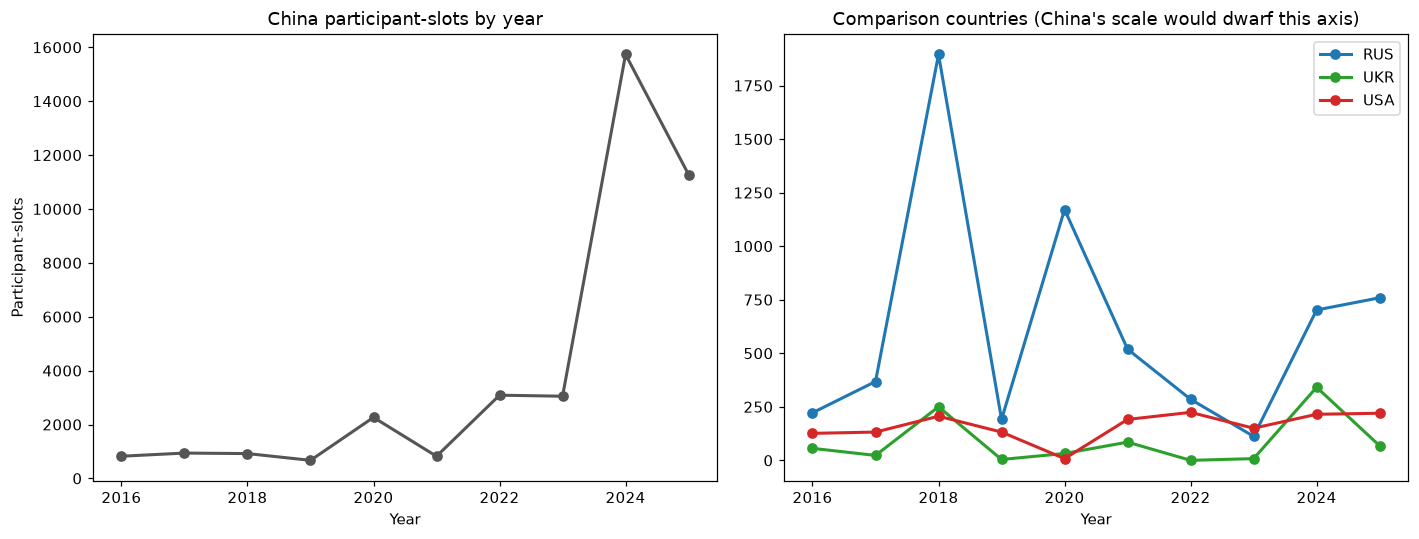

yr     2016   2017    2018   2019    2020   2021    2022    2023     2024     2025
iso3                                                                              
CHN   823.0  940.0   921.0  670.0  2264.0  821.0  3088.0  3050.0  15734.0  11275.0
RUS   222.0  368.0  1895.0  191.0  1171.0  519.0   285.0   112.0    702.0    759.0
UKR    56.0   23.0   250.0    4.0    32.0   85.0     0.0     8.0    341.0     68.0
USA   126.0  132.0   206.0  132.0     8.0  191.0   224.0   150.0    215.0    220.0


In [8]:
focus_s = ["CHN", "RUS", "UKR", "USA"]
yearly_s = yearly_by_country(GRASSROOTS, focus_s, lo=2016, hi=2026, extra_cols=", team_number", value_col="team_number")
yearly_s = yearly_s.reindex(columns=range(2016, 2026), fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(yearly_s.columns, yearly_s.loc["CHN"], "o-", color="#555555", linewidth=2)
axes[0].set_title("China participant-slots by year")
axes[0].set_ylabel("Participant-slots")
axes[0].set_xlabel("Year")

colors2 = {"RUS": "#1f77b4", "UKR": "#2ca02c", "USA": "#d62728"}
for iso3 in ["RUS", "UKR", "USA"]:
    axes[1].plot(yearly_s.columns, yearly_s.loc[iso3], "o-", color=colors2[iso3], linewidth=2, label=iso3)
axes[1].set_title("Comparison countries (China's scale would dwarf this axis)")
axes[1].set_xlabel("Year")
axes[1].legend()

plt.tight_layout()
plt.savefig(Path.cwd() / "_regions_fig_slots_yearly.png", dpi=110)
plt.show()

print(yearly_s.to_string())

**China's participant-slots story is a 2024-2025 step-change, not a
gradual ramp** — oscillating in the 700-3,100 range every year from 2016
through 2023, then jumping to **15,734 in 2024** and staying elevated at
**11,275 in 2025**. This is specifically when the mega-open-qualifier
phenomenon (`grassroots_scene_comparison.ipynb` §3 — China/Asia-Pacific
open brackets running into the thousands of entrants) took off; it isn't
visible at all before 2024. None of the comparison countries shows
anything on this scale — Russia's own volatile peak (1,895 in 2018) is
smaller than China's *pre-2024 baseline year* (2020's 2,264), let alone
its 2024-25 levels.

## 6. Audience language-mix — a current snapshot, not a growth measure

Twitch data cannot be backfilled (CLAUDE.md's "one rule"), so this
project's own live-collected `language_mix_snapshots` only covers
2026-08-31 onward — too short a window to measure growth, by construction.
Shown here as a **current cross-sectional check only**: do the countries
growing on the hosting/participation side also show up as meaningful
Twitch audiences today?

In [9]:
LANGUAGE_TO_COUNTRY = {
    "ko": "KOR", "ja": "JPN", "th": "THA", "vi": "VNM", "id": "IDN", "tl": "PHL",
    "hi": "IND", "ms": "MYS", "he": "ISR",
    "ru": "RUS", "de": "DEU", "fr": "FRA", "it": "ITA", "pl": "POL", "tr": "TUR",
    "uk": "UKR", "cs": "CZE", "hu": "HUN", "el": "GRC", "fi": "FIN", "sv": "SWE",
    "da": "DNK", "no": "NOR", "nl": "NLD", "ro": "ROU", "bg": "BGR", "sk": "SVK",
    "hr": "HRV", "pt": "BRA",
}
AMBIGUOUS = {"en", "es", "zh", "ar", "other"}

lang_rows = conn.execute(
    "SELECT language_code, SUM(viewer_count) AS vt FROM language_mix_snapshots "
    "WHERE title_id='counter_strike' GROUP BY language_code"
).fetchall()
lang_df = pd.DataFrame(lang_rows, columns=["lang", "viewer_time"])
lang_df["iso3"] = lang_df["lang"].map(LANGUAGE_TO_COUNTRY)
total = lang_df["viewer_time"].sum()
lang_df["share_pct"] = lang_df["viewer_time"] / total * 100

mapped_pct = lang_df[lang_df["iso3"].notna()]["share_pct"].sum()
print(f"{mapped_pct:.0f}% of CS viewer-time maps to a specific country\n")
print(lang_df[lang_df["iso3"].notna()].sort_values("share_pct", ascending=False)[["iso3","lang","share_pct"]].head(10).round(2).to_string(index=False))

zh_share = lang_df[lang_df["lang"] == "zh"]["share_pct"].iloc[0]
print(f"\nChinese-language ('zh') share of CS viewer-time: {zh_share:.2f}% -- excluded from country mapping (ambiguous: China, Taiwan, Hong Kong, Singapore, diaspora)")

76% of CS viewer-time maps to a specific country

iso3 lang  share_pct
 RUS   ru      52.20
 BRA   pt       8.91
 POL   pl       5.33
 FRA   fr       2.37
 DEU   de       1.66
 UKR   uk       1.34
 FIN   fi       1.15
 SWE   sv       0.52
 ITA   it       0.41
 DNK   da       0.37

Chinese-language ('zh') share of CS viewer-time: 0.23% -- excluded from country mapping (ambiguous: China, Taiwan, Hong Kong, Singapore, diaspora)


**Russia dominates** (51.6% of all mappable CS viewer-time on
Twitch) — far beyond any other country, consistent with §2's finding that
Russia is also the clearest genuine (not spike-and-crash) grassroots
hosting grower. Czech Republic, despite its own steady hosting growth,
barely registers here (0.05%) — its growth is in hosting/organizing
infrastructure, not a large domestic Twitch audience, at least not yet.

**China stays exactly as structurally invisible here as `china_cs_scene.
ipynb` §7 already found**: Chinese-language viewership is only 0.25% of
all CS viewer-time on Twitch, and even that tiny sliver is excluded from
country-mapping as ambiguous. Not evidence a Chinese audience is small —
Twitch itself is not meaningfully accessible in China (PRD §9.8) — the
hosting-side and participation-side growth (§3, §5) and this audience-side
blank spot are two different facts, not a contradiction.

## 7. Synthesis — no single "fastest-growing region," and the shape matters as much as the direction

Four signals, four different pictures — and now that each has a real
year-by-year shape behind it, "growing" splits further into genuinely
different trajectories, not just different magnitudes.

| Signal | Steady growers | Spike-and-crash (looked like growth, isn't) | Recent step-change | Structurally unmeasured |
|---|---|---|---|---|
| Grassroots tournament count | Russia (accelerating), Czech Republic (gradual) | **Argentina, South Africa** — both now below their 2016 starting level | China (flat 2016-2023, jumped in 2025) | — |
| Participant-slots | — | — | **China** (flat through 2023, 15,734 in 2024) | — |
| Tier-1/2 hosting | Denmark (volatile, real) | — | Saudi Arabia, Mongolia, India, Serbia, Malta (all too new/small to call a trend) | China (two real zero-years, now recovering) |
| Current audience share | Russia (dominant) | — | — | **China** (Twitch inaccessible there) |

Kazakhstan and Uzbekistan (grassroots, near-zero to real presence) sit
outside this table on their own axis — genuinely new scenes, bumpy but
real, with no prior documentation anywhere in this project.

## 8. Bottom line

Restructuring this notebook around real year-by-year trajectories, not
just a two-window ratio, changed two real conclusions, not just added
detail. **Argentina and South Africa are not growing** — both looked like
established growers under the original before/after comparison, but their
full trajectories show a mid-window spike (2022-23) that has since
collapsed to below 2016 levels; the ratio caught the spike's tail and
missed the crash. Russia and Czech Republic remain genuine growers, with
different shapes (Russia volatile-but-accelerating, Czech Republic
gradual-and-steady) worth distinguishing, not collapsing into one "growth"
number. China is not a broad grower by tournament count (essentially flat
2016-2023, one large jump in 2025) but *is* an extreme outlier by
participation scale specifically, and that too is a 2024-only step-change,
not a multi-year ramp. Kazakhstan and Uzbekistan are the closest thing to
an uncomplicated "fastest-growing" story this data supports — genuinely
new scenes, though still too bumpy to call settled. Denmark's tier-1/2
growth is real but has already pulled back from its 2023 peak. Prize
money remains impossible to compare reliably across countries (§4) given
this project's lack of a currency-conversion capability, and China's
audience side stays completely unmeasured, for a structural reason (PRD
§9.8) that has nothing to do with the real growth found elsewhere in this
notebook.